## Importación

In [ ]:
!pip install langdetect

In [ ]:
import pandas as pd
from langdetect import detect

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist

import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("names")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets')
nltk.download('tagsets_json')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package tagsets_json 

True

In [ ]:
STOPWORDS = nltk.corpus.stopwords.words("english")
NAMES = nltk.corpus.names.words()

## Análisis Exploratorio de la Data (EDA)

In [ ]:
df = pd.read_csv("new_delhi_reviews.csv")
# obtained from https://www.kaggle.com/datasets/arnabchaki/tripadvisor-reviews-2023

In [ ]:
df

,rating_review,review_full
0,5,"Totally in love with the Auro of the place, re..."
1,5,I went this bar 8 days regularly with my husba...
2,5,We were few friends and was a birthday celebra...
3,5,Fatjar Cafe and Market is the perfect place fo...
4,5,"Hey Guys, if you are craving for pizza and sea..."
...,...,...
147576,5,Near by airport very calm and cool environment...
147577,5,My favourite place to stay. Great service. Ash...
147578,5,"good food with nice decoration, drinks list al..."
147579,4,Near to airport .it is fine property. Staff i...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147581 entries, 0 to 147580
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   rating_review  147581 non-null  int64 
 1   review_full    147579 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [ ]:
df["review_full"] = df["review_full"].astype(str)

In [ ]:
df.iloc[0]["review_full"]

"Totally in love with the Auro of the place, really beautiful and quite fancy at the same time. The ambience is very pure and gives a sense of positivity throughout. Outdoor and indoor interior are quite quaint and cute. Love the open kitchen idea and there whole marketplace ideology. Due to coronovirus they specifically use disposable cutlery to keep the pandemic in mind taking all the precautionary measures from the beginning of the place with the mask on their staff and using good sanitisation. The food is really amazing specially the pizza straight from the oven and the hummus and pita bread are quite delicious too. If you're looking for a classy yet soothing Italian place in Delhi,Fatjar is a go to for you!"

<Axes: xlabel='rating_review'>

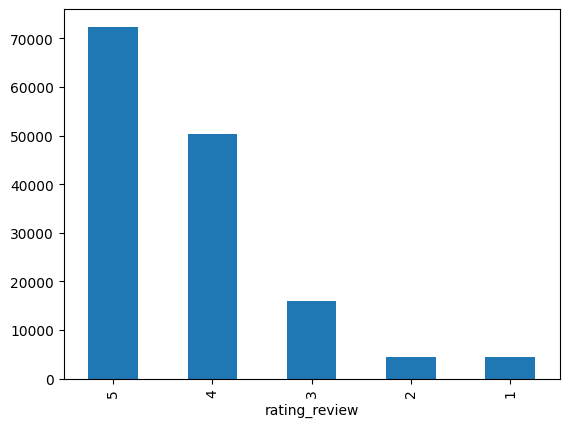

In [ ]:
df["rating_review"].value_counts().plot(kind="bar")

In [ ]:
df["sentiment"] = df["rating_review"].apply(lambda x: "positive" if x >= 3 else "negative")
df

,rating_review,review_full,sentiment
0,5,"Totally in love with the Auro of the place, re...",positive
1,5,I went this bar 8 days regularly with my husba...,positive
2,5,We were few friends and was a birthday celebra...,positive
3,5,Fatjar Cafe and Market is the perfect place fo...,positive
4,5,"Hey Guys, if you are craving for pizza and sea...",positive
...,...,...,...
147576,5,Near by airport very calm and cool environment...,positive
147577,5,My favourite place to stay. Great service. Ash...,positive
147578,5,"good food with nice decoration, drinks list al...",positive
147579,4,Near to airport .it is fine property. Staff i...,positive


<Axes: xlabel='sentiment'>

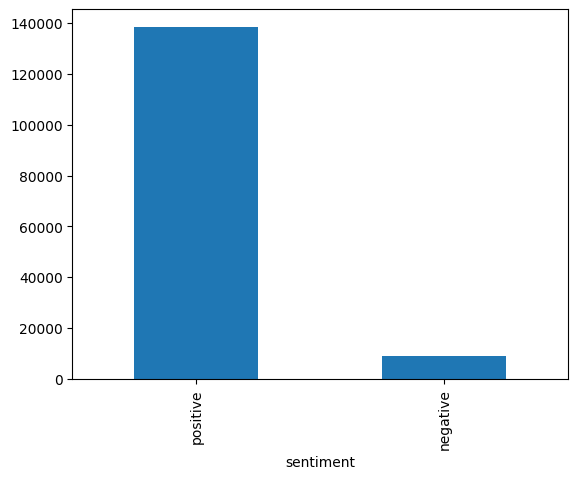

In [ ]:
df["sentiment"].value_counts().plot(kind="bar")

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,138574
negative,9007


In [ ]:
df["sentiment"].value_counts(normalize=True)

,proportion
sentiment,
positive,0.938969
negative,0.061031


### Balanceo de target

In [ ]:
# Tecnicas de balanceo de etiqueta
# Undersampling
# Oversampling
# Hibrido

# En este caso aplicaremos undersampling
min_size_of_target_class = df["sentiment"].value_counts().min()

df = pd.concat([
    df[df["sentiment"] == target].sample(min_size_of_target_class) for target in df["sentiment"].unique()
])
df

,rating_review,review_full,sentiment
3524,4,You feel like royalty when you step inside. G...,positive
117117,5,I love this place too much the restaurant staf...,positive
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive
132627,4,"Finally a saviour for me near my place, where ...",positive
...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative
72358,2,If restaurants were rated simply for decor and...,negative
132974,1,We visited the restaurant with friends and eve...,negative


In [ ]:
df["language"] = df["review_full"].apply(lambda x: detect(x))
df

,rating_review,review_full,sentiment,language
3524,4,You feel like royalty when you step inside. G...,positive,en
117117,5,I love this place too much the restaurant staf...,positive,en
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en
132627,4,"Finally a saviour for me near my place, where ...",positive,en
...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en
72358,2,If restaurants were rated simply for decor and...,negative,en
132974,1,We visited the restaurant with friends and eve...,negative,en


In [ ]:
df["language"].value_counts()

,count
language,
en,18007
vi,3
fr,2
ja,1
ko,1


In [ ]:
# Identificando filas a eliminar
df[df["language"] != "en"]

,rating_review,review_full,sentiment,language
129543,4,#NAME?,positive,vi
61012,4,#NAME?,positive,vi
146672,5,Excellent service bu shubham n vikas Love to c...,positive,fr
110820,5,"Fantastic, personable service. Excellent atten...",positive,fr
32703,1,#NAME?,negative,vi
115521,2,はっきり言って、ここはレストランというよりは、ファーストフード店ですね。お手洗い、トイレット...,negative,ja
90950,1,"when we eating, roach come out on table. the s...",negative,ko


In [ ]:
df = df[df["language"] == "en"]
df

,rating_review,review_full,sentiment,language
3524,4,You feel like royalty when you step inside. G...,positive,en
117117,5,I love this place too much the restaurant staf...,positive,en
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en
132627,4,"Finally a saviour for me near my place, where ...",positive,en
...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en
72358,2,If restaurants were rated simply for decor and...,negative,en
132974,1,We visited the restaurant with friends and eve...,negative,en


In [ ]:
df["prompt_length"] = df["review_full"].apply(lambda x: len(x))
df

<ipython-input-85-415c4d40b52a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prompt_length"] = df["review_full"].apply(lambda x: len(x))


,rating_review,review_full,sentiment,language,prompt_length
3524,4,You feel like royalty when you step inside. G...,positive,en,177
117117,5,I love this place too much the restaurant staf...,positive,en,124
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en,260
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en,104
132627,4,"Finally a saviour for me near my place, where ...",positive,en,1612
...,...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en,1907
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en,270
72358,2,If restaurants were rated simply for decor and...,negative,en,483
132974,1,We visited the restaurant with friends and eve...,negative,en,738


<Axes: >

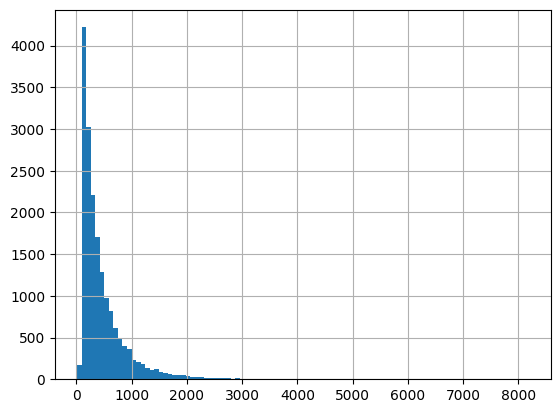

In [ ]:
df["prompt_length"].hist(bins=100)

In [ ]:
# Revisando los outliers en terminos de tamaño
df[df["prompt_length"] > 1000]
#df.loc[66475]["review_full"]

,rating_review,review_full,sentiment,language,prompt_length
132627,4,"Finally a saviour for me near my place, where ...",positive,en,1612
138831,3,"Being a fan of keventers over the years, went ...",positive,en,1005
101149,5,"If you are a meat-lover and in Delhi, this is ...",positive,en,2009
69207,5,"An uber chic restaurant, with utmost vibrancy ...",positive,en,1031
6558,4,We went here for brunch and were enthralled wi...,positive,en,1321
...,...,...,...,...,...
118949,2,My girlfriend and I visited this place twice w...,negative,en,1359
69210,2,The hotel is okay for what it is is - a centra...,negative,en,1295
61845,2,I have been here three to four times now and t...,negative,en,1696
88050,2,Have been eating at this joint for at least te...,negative,en,1661


In [ ]:
# Revisando los outliers en terminos de tamaño
df[df["prompt_length"] < 25]
#df.loc[41467]["review_full"]

,rating_review,review_full,sentiment,language,prompt_length
41467,2,Highly overrated....,negative,en,20


In [ ]:
df = df[df["prompt_length"] > 20]
df

,rating_review,review_full,sentiment,language,prompt_length
3524,4,You feel like royalty when you step inside. G...,positive,en,177
117117,5,I love this place too much the restaurant staf...,positive,en,124
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en,260
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en,104
132627,4,"Finally a saviour for me near my place, where ...",positive,en,1612
...,...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en,1907
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en,270
72358,2,If restaurants were rated simply for decor and...,negative,en,483
132974,1,We visited the restaurant with friends and eve...,negative,en,738


## Preprocesamiento de texto

In [ ]:
df.iloc[0]["review_full"]

'You feel like royalty when you step inside.  Great cutlery and warmed plates.  Slightly over priced but certainly will return.  Do try their palak patta, the best I have tasted.'

In [ ]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

In [ ]:
# Stemmer
simplifier = PorterStemmer()
# Lematizador
#simplifier = WordNetLemmatizer()

In [ ]:
# Guardar los archivos necesarios para preprocesar texto
with open("model/simplifier.pkl", "wb") as f:
  pickle.dump(simplifier, f)

In [ ]:
def get_tokens(review, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    cleaned_tokens.append(token)

  return cleaned_tokens

In [ ]:
get_tokens(df.iloc[0]["review_full"])

['feel',
 'royalty',
 'step',
 'great',
 'cutlery',
 'warmed',
 'plates',
 'slightly',
 'priced',
 'certainly',
 'return',
 'try',
 'palak',
 'patta',
 'best',
 'tasted']

In [ ]:
df["tokens"] = df["review_full"].apply(lambda x: get_tokens(x, simplifier_func=simplifier.stem))
df

<ipython-input-96-23c3bec5a335>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"] = df["review_full"].apply(lambda x: get_tokens(x, simplifier_func=simplifier.stem))


,rating_review,review_full,sentiment,language,prompt_length,tokens
3524,4,You feel like royalty when you step inside. G...,positive,en,177,"[feel, royalti, step, great, cutleri, warm, pl..."
117117,5,I love this place too much the restaurant staf...,positive,en,124,"[love, place, much, restaur, staff, nice, alwa..."
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en,260,"[enjoy, skybar, inspit, delhi, summer, great, ..."
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en,104,"[swagat, dhaba, paharganj, basic, dhaba, food,..."
132627,4,"Finally a saviour for me near my place, where ...",positive,en,1612,"[final, saviour, place, sit, hour, enjoy, ever..."
...,...,...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en,1907,"[visit, talk, place, west, delhi, charm, young..."
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en,270,"[burnt, food, cold, appet, smelli, drink, quar..."
72358,2,If restaurants were rated simply for decor and...,negative,en,483,"[restaur, rate, simpli, decor, ambienc, place,..."
132974,1,We visited the restaurant with friends and eve...,negative,en,738,"[visit, restaur, friend, everyth, went, bad, b..."


## Análisis del vocabulario y selección de features

In [ ]:
full_vocabulary = []
vocabulary = {category: [] for category in df["sentiment"].unique()}
for _, row in df.iterrows():
  tokens = row["tokens"]
  sentiment = row["sentiment"]
  vocabulary[sentiment] += tokens
  full_vocabulary += tokens

In [ ]:
print(f"Cantidad de tokens del vocabulario: {len(FreqDist(full_vocabulary))}")

Cantidad de tokens del vocabulario: 21323


In [ ]:
FreqDist(full_vocabulary).most_common(500)

[('food', 17960),
 ('place', 12077),
 ('good', 9785),
 ('restaur', 8547),
 ('servic', 7888),
 ('order', 6876),
 ('serv', 5385),
 ('visit', 5222),
 ('time', 5084),
 ('tast', 4924),
 ('staff', 4554),
 ('chicken', 4528),
 ('even', 4069),
 ('go', 4068),
 ('dish', 3809),
 ('great', 3729),
 ('tri', 3620),
 ('tabl', 3412),
 ('also', 3400),
 ('experi', 3346),
 ('realli', 3111),
 ('get', 3104),
 ('delhi', 3081),
 ('menu', 3074),
 ('indian', 2833),
 ('ask', 2767),
 ('well', 2754),
 ('nice', 2743),
 ('manag', 2562),
 ('price', 2561),
 ('went', 2540),
 ('qualiti', 2496),
 ('recommend', 2441),
 ('drink', 2441),
 ('best', 2363),
 ('look', 2225),
 ('eat', 2224),
 ('love', 2175),
 ('friend', 2154),
 ('ambienc', 2142),
 ('much', 2096),
 ('come', 2096),
 ('make', 2037),
 ('bad', 2037),
 ('wait', 2024),
 ('meal', 2002),
 ('peopl', 1977),
 ('want', 1954),
 ('better', 1934),
 ('dinner', 1898),
 ('back', 1896),
 ('waiter', 1891),
 ('first', 1843),
 ('disappoint', 1818),
 ('take', 1755),
 ('never', 1721),
 (

In [ ]:
most_common_tokens = set()
for category in df["sentiment"].unique():
  most_common_tokens = most_common_tokens.union(set([token for token, _ in FreqDist(vocabulary[category]).most_common(500)]))
most_common_tokens

{'absolut',
 'accept',
 'actual',
 'ad',
 'add',
 'alcohol',
 'almost',
 'aloo',
 'alreadi',
 'also',
 'alway',
 'amaz',
 'ambianc',
 'ambienc',
 'amount',
 'anyon',
 'anyth',
 'apolog',
 'appet',
 'area',
 'arrang',
 'arriv',
 'asian',
 'ask',
 'ate',
 'atmospher',
 'attend',
 'attent',
 'attitud',
 'authent',
 'avail',
 'averag',
 'avoid',
 'aw',
 'away',
 'awesom',
 'back',
 'bad',
 'bake',
 'bar',
 'base',
 'basic',
 'beauti',
 'beer',
 'believ',
 'best',
 'better',
 'big',
 'bill',
 'birthday',
 'biryani',
 'bit',
 'bite',
 'black',
 'bland',
 'book',
 'bother',
 'bottl',
 'brand',
 'bread',
 'breakfast',
 'bring',
 'brought',
 'browni',
 'buffet',
 'bukhara',
 'burger',
 'busi',
 'butter',
 'cafe',
 'cake',
 'call',
 'came',
 'card',
 'care',
 'case',
 'celebr',
 'chaat',
 'chang',
 'charg',
 'cheap',
 'check',
 'chees',
 'chef',
 'chicken',
 'chill',
 'chilli',
 'chines',
 'chocol',
 'choic',
 'choos',
 'chutney',
 'citi',
 'class',
 'clean',
 'close',
 'cocktail',
 'coffe',
 'c

In [ ]:
print(f"Cantidad de tokens comunes: {len(most_common_tokens)}")

Cantidad de tokens comunes: 624


In [ ]:
# Guardar los archivos necesarios para preprocesar texto
with open("model/most_common_tokens.pkl", "wb") as f:
  pickle.dump(most_common_tokens, f)

### Update de la función obtener tokens

In [ ]:
def get_tokens_training(review, most_common_tokens, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    if token not in most_common_tokens: continue
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

## Vectorización

In [ ]:
get_tokens_training("I like the food, it was excellent", most_common_tokens, simplifier_func=simplifier.stem)

'food excel'

In [ ]:
df["token_string"] = df["review_full"].apply(lambda x: get_tokens_training(x, most_common_tokens, simplifier_func=simplifier.stem))
df

<ipython-input-105-9ecabea6816a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["token_string"] = df["review_full"].apply(lambda x: get_tokens_training(x, most_common_tokens, simplifier_func=simplifier.stem))


,rating_review,review_full,sentiment,language,prompt_length,tokens,token_string
3524,4,You feel like royalty when you step inside. G...,positive,en,177,"[feel, royalti, step, great, cutleri, warm, pl...",feel great warm plate price return tri best tast
117117,5,I love this place too much the restaurant staf...,positive,en,124,"[love, place, much, restaur, staff, nice, alwa...",love place much restaur staff nice alway help ...
61409,4,Enjoyed being at the skybar inspite of Delhi's...,positive,en,260,"[enjoy, skybar, inspit, delhi, summer, great, ...",enjoy delhi great set good food order meal tha...
90621,3,Swagat Dhaba paharganj was basically a dhaba. ...,positive,en,104,"[swagat, dhaba, paharganj, basic, dhaba, food,...",dhaba basic dhaba food averag dhaba servic
132627,4,"Finally a saviour for me near my place, where ...",positive,en,1612,"[final, saviour, place, sit, hour, enjoy, ever...",final place sit hour enjoy everyth shake food ...
...,...,...,...,...,...,...,...
71624,2,So i visited one of the most talked about plac...,negative,en,1907,"[visit, talk, place, west, delhi, charm, young...",visit talk place delhi crowd first realli get ...
25820,1,"Burnt food, cold appetizers, smelly drinks, qu...",negative,en,270,"[burnt, food, cold, appet, smelli, drink, quar...",food cold appet drink waiter set experi parti ...
72358,2,If restaurants were rated simply for decor and...,negative,en,483,"[restaur, rate, simpli, decor, ambienc, place,...",restaur rate simpli decor ambienc place still ...
132974,1,We visited the restaurant with friends and eve...,negative,en,738,"[visit, restaur, friend, everyth, went, bad, b...",visit restaur friend everyth went bad waiter r...


In [ ]:
vectorizer = TfidfVectorizer()
vectorizer.fit(df["token_string"])

TfidfVectorizer()

In [ ]:
X = pd.DataFrame(
    vectorizer.transform(df["token_string"]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)
X

,absolut,accept,actual,ad,add,alcohol,almost,aloo,alreadi,also,...,world,wors,worst,worth,write,wrong,ye,year,yet,yummi
3524,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
117117,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
61409,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
90621,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
132627,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.071,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71624,0.0,0.0,0.0,0.0,0.0,0.208417,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
25820,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
72358,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
132974,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.389708,0.0,0.000,0.0,0.0,0.0


In [ ]:
with open("model/vectorizer.pkl", "wb") as f:
  pickle.dump(vectorizer, f)

## Entrenamiento del modelo

In [ ]:
y = df["sentiment"].sample(frac=1)
y

,sentiment
100256,positive
79946,negative
53157,negative
80326,negative
21725,negative
...,...
85809,negative
55651,negative
22829,negative
63667,positive


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = KNeighborsClassifier(n_neighbors=10)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
result = pd.concat([
    y_test.rename("real"),
    pd.Series(model.predict(X_test), index=y_test.index, name="predicted")
], axis=1)
result

,real,predicted
53661,negative,positive
87023,negative,positive
52898,positive,negative
42690,negative,negative
46762,positive,negative
...,...,...
78970,negative,positive
43004,positive,negative
48159,negative,negative
133797,positive,negative


In [ ]:
print(f"El accuracy es: {accuracy_score(result['real'], result['predicted'])}")
print(f"El precision es: {precision_score(result['real'], result['predicted'], pos_label='positive')}")
print(f"El recall es: {recall_score(result['real'], result['predicted'], pos_label='positive')}")
print(f"El f1 es: {f1_score(result['real'], result['predicted'], pos_label='positive')}")

El accuracy es: 0.502776235424764
El precision es: 0.4985507246376812
El recall es: 0.38500279798545045
El f1 es: 0.4344805809914746


In [ ]:
print(classification_report(result["real"], result["predicted"]))

              precision    recall  f1-score   support

    negative       0.51      0.62      0.56      1815
    positive       0.50      0.39      0.43      1787

    accuracy                           0.50      3602
   macro avg       0.50      0.50      0.50      3602
weighted avg       0.50      0.50      0.50      3602



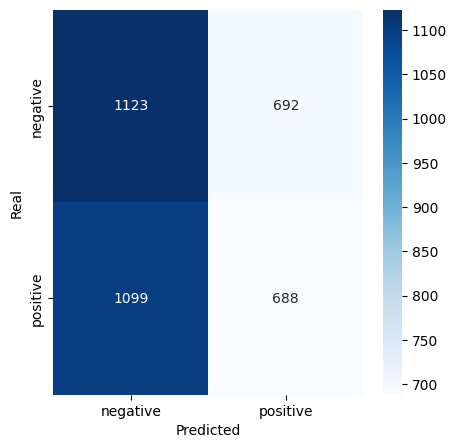

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = result["real"].unique()
cf = confusion_matrix(result["real"], result["predicted"], labels=labels)
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cf, annot=True, cmap="Blues", fmt="d", ax=ax, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Real")
print("")

In [ ]:
## Probar con varios modelos
models = [KNeighborsClassifier, RandomForestClassifier, MultinomialNB, LogisticRegression]

for model in models:
  model = model()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"El accuracy del modelo es: {accuracy_score(y_test, y_pred)}")

El accuracy del modelo es: 0.49305941143808996
El accuracy del modelo es: 0.5047196002220988
El accuracy del modelo es: 0.5016657412548584
El accuracy del modelo es: 0.5036091060521932


In [ ]:
with open("model/model.pkl", "wb") as f:
  pickle.dump(model, f)

## Simulación de espacio productivo

In [ ]:
df_inference = pd.read_csv("New_Delhi_reviews.csv")

In [ ]:
with open("model/vectorizer.pkl", "rb") as f:
  vectorizer_inference = pickle.load(f)

In [ ]:
with open("model/model.pkl", "rb") as f:
  model_inference = pickle.load(f)

In [ ]:
with open("model/most_common_tokens.pkl", "rb") as f:
  most_common_tokens_inference = pickle.load(f)

In [ ]:
with open("model/simplifier.pkl", "rb") as f:
  simplifier_inference = pickle.load(f)

In [ ]:
def get_tokens_inference(review, most_common_tokens, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in NAMES: continue
    token = token.lower()
    if token in STOPWORDS: continue
    if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
    if simplifier_func: token = simplifier_func(token)
    if token not in most_common_tokens: continue
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

In [ ]:
df_inference["token_string"] = df_inference["review_full"].apply(lambda x: get_tokens_inference(x, most_common_tokens_inference, simplifier_func=simplifier_inference.stem))
X_inference = pd.DataFrame(
    vectorizer_inference.transform(df_inference["token_string"]).toarray(),
    columns=vectorizer_inference.get_feature_names_out(),
    index=df_inference.index
)
y_inference = model_inference.predict(X_inference)

TypeError: expected string or bytes-like object, got 'float'